# LLM-as-a-Judge Filter

Notebook to apply a basic LLM-as-a-Judge filter on 3 datasets:
- ASQA test set (newly created by splitting the original ASQA train set)
- MS Macro (500 longest answers from the original test set)
- WikiEval 

This is to compare the performance of the filter with RAGAS filter.


## Imports and setup    

In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys
import json
from dotenv import load_dotenv

import pandas as pd
import numpy as np

from IPython.display import display

# Nếu notebook nằm trong notebooks/, append project root
sys.path.append('..')

from src.filtering.llm_judge_filter import LLMJudgeFilter
from src.evaluation.filter_evaluator import FilterEvaluator, plot_evaluation_results


load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
HUGGINGFACE_API_KEY = os.getenv("HUGGINGFACE_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# ============================================================
# Paths
# ============================================================

MS_PATH = Path('../data/ms-macro/labeled_msmacro.csv')
WIKI_PATH = Path('../data/wikiEval/labeled_wikieval.csv')
ASQA_PATH = Path('../data/asqa/labeled_asqa_test.csv')

OUTPUT_DIR = Path('../results/llm_filter')
OUTPUT_FILTER = OUTPUT_DIR / 'classification'
OUTPUT_FILTER.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'msmacro': MS_PATH,
    'wikieval': WIKI_PATH,
    'asqa_test': ASQA_PATH,
}

for name, path in DATASETS.items():
    print(f'{name}: {path} | exists={path.exists()}')

print(f'Output dir: {OUTPUT_FILTER}')

msmacro: ..\data\ms-macro\labeled_msmacro.csv | exists=True
wikieval: ..\data\wikiEval\labeled_wikieval.csv | exists=True
asqa_test: ..\data\asqa\labeled_asqa_test.csv | exists=True
Output dir: ..\results\llm_filter\classification


## Imports data

In [5]:
# ============================================================
# Quick schema check
# ============================================================

REQUIRED_COLS = {'id', 'question', 'answer', 'context'}
OPTIONAL_EVAL_COLS = {'label', 'gold_ans', 'gold_answer', 'reference', 'reference_answer', 'ground_truth'}

def preview_dataset(name: str, path: Path, n: int = 2):
    if not path.exists():
        print(f'[SKIP] {name}: file not found: {path}')
        return None

    df = pd.read_csv(path)
    missing = REQUIRED_COLS - set(df.columns)

    print('=' * 80)
    print(name)
    print(f'Path: {path}')
    print(f'Shape: {df.shape}')
    print(f'Columns: {list(df.columns)}')

    if missing:
        print(f'[WARNING] Missing required columns: {missing}')
    else:
        print('[OK] Required columns exist.')

    eval_cols = sorted(set(df.columns) & OPTIONAL_EVAL_COLS)
    print(f'Eval columns found: {eval_cols}')

    display(df.head(n))
    return df

previews = {name: preview_dataset(name, path) for name, path in DATASETS.items()}

msmacro
Path: ..\data\ms-macro\labeled_msmacro.csv
Shape: (1000, 5)
Columns: ['id', 'question', 'context', 'answer', 'label']
[OK] Required columns exist.
Eval columns found: ['label']


,id,question,context,answer,label
0,10736,buying a car dealer vs. private seller,[P1] Source: http://www.consumerhelp.ie/buying...,Traders are often called “dealers” and sell ca...,1
1,12719,convert dollar pay into salary to twice a month,[P1] Source: http://www.ehow.com/how_12044390_...,Determine what your paydays will be throughout...,1


wikieval
Path: ..\data\wikiEval\labeled_wikieval.csv
Shape: (100, 5)
Columns: ['id', 'question', 'context', 'answer', 'label']
[OK] Required columns exist.
Eval columns found: ['label']


,id,question,context,answer,label
0,0_pos,When is the scheduled launch date and time for...,The PSLV-C56 is the 58th mission of Indian Spa...,The PSLV-C56 mission is scheduled to be launch...,1
1,0_neg,When is the scheduled launch date and time for...,The PSLV-C56 is the 58th mission of Indian Spa...,The scheduled launch date and time for the PSL...,0


asqa_test
Path: ..\data\asqa\labeled_asqa_test.csv
Shape: (1742, 5)
Columns: ['id', 'question', 'context', 'answer', 'label']
[OK] Required columns exist.
Eval columns found: ['label']


,id,question,context,answer,label
0,asqa_1881_hallu,What is the new wizard of oz movie called?,- (Oz the Great and Powerful) There are severa...,"There are several new ""Wizard of Oz"" movies. ""...",0
1,asqa_9_hallu,When does doctor strange get the infinity stone?,- (Infinity Gems) In the animated direct-to-vi...,"In the animated direct-to-video film, Doctor S...",0


## Initialize LLM Judge Filter & Evaluator

In [6]:
# ============================================================
# Init LLM Judge
# ============================================================

# LLMJudgeFilter sẽ đọc OPENAI_API_KEY từ environment.

judge = LLMJudgeFilter(
    model='gpt-4o-mini',
    api_key=OPENAI_API_KEY,
    output_dir=OUTPUT_FILTER,
    temperature=0.0,
    max_retries=3,
    sleep_between_retries=2.0,
    max_context_chars=12000,
)

filter_evaluator = FilterEvaluator(
    label_col='label',
    answer_col='answer',
    context_col='context',
    output_dir=OUTPUT_FILTER,
)




In [7]:
# ============================================================
# Run LLM judge on one dataset
# ============================================================

def run_llm_judge_dataset(
    name: str,
    data_path: Path,
    eval_mode: str = 'classification',
    resume: bool = True,
    save_every: int = 1,
):
    if not data_path.exists():
        print(f'[SKIP] {name}: file not found: {data_path}')
        return None

    dataset_out_dir = OUTPUT_FILTER / name
    dataset_out_dir.mkdir(parents=True, exist_ok=True)

    prediction_path = dataset_out_dir / f'{name}_llm_judge_predictions.csv'

    print('=' * 80)
    print(f'Running LLM judge: {name}')
    print(f'Input: {data_path}')
    print(f'Output: {prediction_path}')

    # predict() có resume bằng output_path.
    # save_every=1 để sample nào judge xong là ghi ra file liền.
    out = judge.run(
        data=data_path,
        output_path=prediction_path,
        eval_mode=eval_mode,
        resume=resume,
        save_every=save_every,
    )
    pred_df = pd.read_csv(prediction_path)
    eval_result = out['evaluation']
    plot_evaluation_results(eval_result, data_name=name)

    return {
        'name': name,
        'prediction_path': prediction_path,
        'pred_df': pred_df,
        'evaluation': eval_result,
    }

## Run evaluation on ASQA, MS Macro, WikiEval

Running LLM judge: msmacro
Input: ..\data\ms-macro\labeled_msmacro.csv
Output: ..\results\llm_filter\classification\msmacro\msmacro_llm_judge_predictions.csv
Found 260 completed samples. Resuming from last checkpoint.
last 5 completed ids: ['11626', '12042', '16640', '18988', '17145']


LLM Judge (gpt-4o-mini): 100%|██████████| 740/740 [26:25<00:00,  2.14s/sample]  



Classification Metrics for msmacro:
  accuracy: 0.916
  precision: 0.9976076555023924
  recall: 0.834
  f1: 0.9084967320261438
  roc_auc: 0.752654


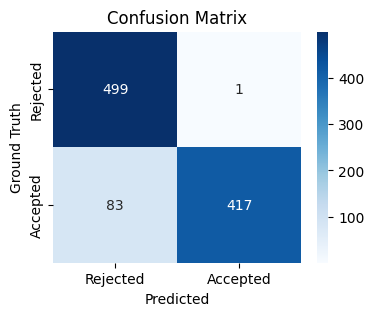

,precision,recall,f1-score,support
0,0.8574,0.998,0.9224,500.000
1,0.9976,0.834,0.9085,500.000
accuracy,0.9160,0.916,0.9160,0.916
macro avg,0.9275,0.916,0.9154,1000.000
weighted avg,0.9275,0.916,0.9154,1000.000


Running LLM judge: wikieval
Input: ..\data\wikiEval\labeled_wikieval.csv
Output: ..\results\llm_filter\classification\wikieval\wikieval_llm_judge_predictions.csv


LLM Judge (gpt-4o-mini): 100%|██████████| 100/100 [03:39<00:00,  2.20s/sample]


Classification Metrics for wikieval:
  accuracy: 0.93
  precision: 0.9056603773584906
  recall: 0.96
  f1: 0.9320388349514563
  roc_auc: 0.8779999999999999


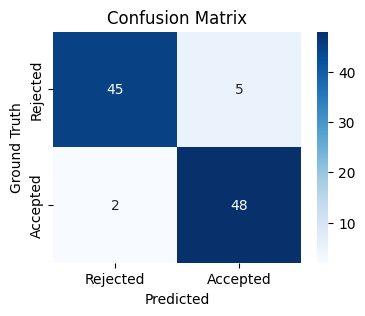

,precision,recall,f1-score,support
0,0.9574,0.90,0.9278,50.00
1,0.9057,0.96,0.9320,50.00
accuracy,0.9300,0.93,0.9300,0.93
macro avg,0.9316,0.93,0.9299,100.00
weighted avg,0.9316,0.93,0.9299,100.00


Running LLM judge: asqa_test
Input: ..\data\asqa\labeled_asqa_test.csv
Output: ..\results\llm_filter\classification\asqa_test\asqa_test_llm_judge_predictions.csv


LLM Judge (gpt-4o-mini): 100%|██████████| 1742/1742 [56:42<00:00,  1.95s/sample] 



Classification Metrics for asqa_test:
  accuracy: 0.8490241102181401
  precision: 0.9510385756676558
  recall: 0.7359357060849598
  f1: 0.8297734627831715
  roc_auc: 0.6680933405919269


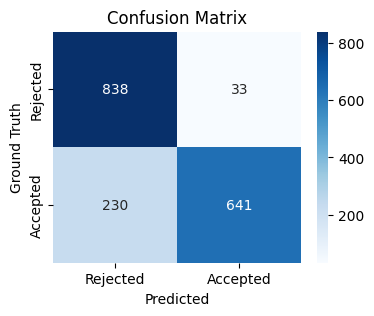

,precision,recall,f1-score,support
0,0.7846,0.9621,0.8644,871.000
1,0.9510,0.7359,0.8298,871.000
accuracy,0.8490,0.8490,0.8490,0.849
macro avg,0.8678,0.8490,0.8471,1742.000
weighted avg,0.8678,0.8490,0.8471,1742.000


Done.


In [9]:
# ============================================================
# Run all datasets
# ============================================================

all_results = {}

for dataset_name, dataset_path in DATASETS.items():
    result = run_llm_judge_dataset(
        name=dataset_name,
        data_path=dataset_path,
        eval_mode='classification',  # đổi thành 'both' nếu muốn thêm quality eval
        resume=True,
        save_every=20,
    )

    if result is not None:
        all_results[dataset_name] = result

print('Done.')

In [10]:
# ============================================================
# Summary table across datasets
# ============================================================

summary_rows = []

for name, result in all_results.items():
    metrics = result.get('evaluation', {}).get('classification')
    if not metrics:
        continue

    pred_df = result['pred_df']
    summary_rows.append({
        'dataset': name,
        'num_samples': len(pred_df),
        'accepted': int(pred_df['filter_label'].sum()),
        'acceptance_rate': float(pred_df['filter_label'].mean()),
        'accuracy': metrics.get('accuracy'),
        'precision': metrics.get('precision'),
        'recall': metrics.get('recall'),
        'f1': metrics.get('f1'),
        'roc_auc': metrics.get('roc_auc'),
        'prediction_path': str(result['prediction_path']),
    })

summary_df = pd.DataFrame(summary_rows)

if len(summary_df):
    display(summary_df.round(4))
    summary_path = OUTPUT_FILTER / 'llm_judge_summary.csv'
    summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')
    print(f'Saved summary to: {summary_path}')
else:
    print('No summary available.')

,dataset,num_samples,accepted,acceptance_rate,accuracy,precision,recall,f1,roc_auc,prediction_path
0,msmacro,1000,418,0.4180,0.916,0.9976,0.8340,0.9085,0.7527,..\results\llm_filter\classification\msmacro\m...
1,wikieval,100,53,0.5300,0.930,0.9057,0.9600,0.9320,0.8780,..\results\llm_filter\classification\wikieval\...
2,asqa_test,1742,674,0.3869,0.849,0.9510,0.7359,0.8298,0.6681,..\results\llm_filter\classification\asqa_test...


Saved summary to: ..\results\llm_filter\classification\llm_judge_summary.csv
